# Clustering des données immobilières californiennes
## Bloc IA — Prosit 1

Ce notebook implémente le pipeline de clustering décrit dans le rapport :
1. Chargement et nettoyage des données
2. Sélection et standardisation des variables
3. Méthode du coude (Elbow Method) — WCSS
4. KMeans (k=6)
5. Visualisation et export du dataset transformé

## 1. Chargement et exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams['figure.figsize'] = (12, 8)
sns.set()
sns.set_context('talk')

In [2]:
# Chargement du dataset imputé par KNN
housing = pd.read_csv('./data/housing_data_knn.csv')
print(f"Shape : {housing.shape}")
housing.head()

Shape : (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
# Valeurs manquantes
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## 2. Règles de nettoyage et préparation du dataset

D'après le rapport, le pipeline de transformation suit ces règles :

1. **Sélection des variables** : on retient uniquement `latitude`, `longitude`, `median_income` et `median_house_value`. Ces 4 variables captent la position géographique et le profil socio-économique.
2. **Gestion des valeurs manquantes** : seule `total_bedrooms` a 207 valeurs nulles, mais elle n'est pas utilisée pour le clustering. Les 4 variables sélectionnées n'ont aucune valeur manquante → aucune suppression de ligne nécessaire.
3. **Standardisation** : `StandardScaler` (centrage-réduction) pour que chaque variable ait la même influence sur la distance euclidienne.
4. **Pas de suppression d'outliers** : le rapport ne mentionne aucun filtre sur les valeurs extrêmes.

In [5]:
# Sélection des 4 variables pour le clustering
features = ['latitude', 'longitude', 'median_income', 'median_house_value']
X = housing[features].copy()

# Vérification : aucune valeur manquante sur ces 4 colonnes
print("Valeurs manquantes sur les variables de clustering :")
print(X.isnull().sum())
print(f"\nLignes avant nettoyage : {len(X)}")

# Suppression des éventuelles lignes avec NaN (0 dans notre cas)
X = X.dropna()
print(f"Lignes après nettoyage : {len(X)}")

Valeurs manquantes sur les variables de clustering :
latitude              0
longitude             0
median_income         0
median_house_value    0
dtype: int64

Lignes avant nettoyage : 20640
Lignes après nettoyage : 20640


In [6]:
# Standardisation (centrage-réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Moyennes après standardisation :", X_scaled.mean(axis=0).round(2))
print("Écarts-types après standardisation :", X_scaled.std(axis=0).round(2))

Moyennes après standardisation : [ 0. -0.  0. -0.]
Écarts-types après standardisation : [1. 1. 1. 1.]


## 3. Méthode du coude (Elbow Method) — WCSS

In [7]:
# Calcul du WCSS pour k de 2 à 15
k_range = range(2, 16)
wcss = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(f"k={k:2d}  WCSS={kmeans.inertia_:.0f}")

k= 2  WCSS=47374
k= 3  WCSS=31659
k= 4  WCSS=24716
k= 5  WCSS=20717
k= 6  WCSS=18405
k= 7  WCSS=16522
k= 8  WCSS=14633
k= 9  WCSS=13460
k=10  WCSS=12504
k=11  WCSS=11710
k=12  WCSS=11009
k=13  WCSS=10386
k=14  WCSS=9862
k=15  WCSS=9299


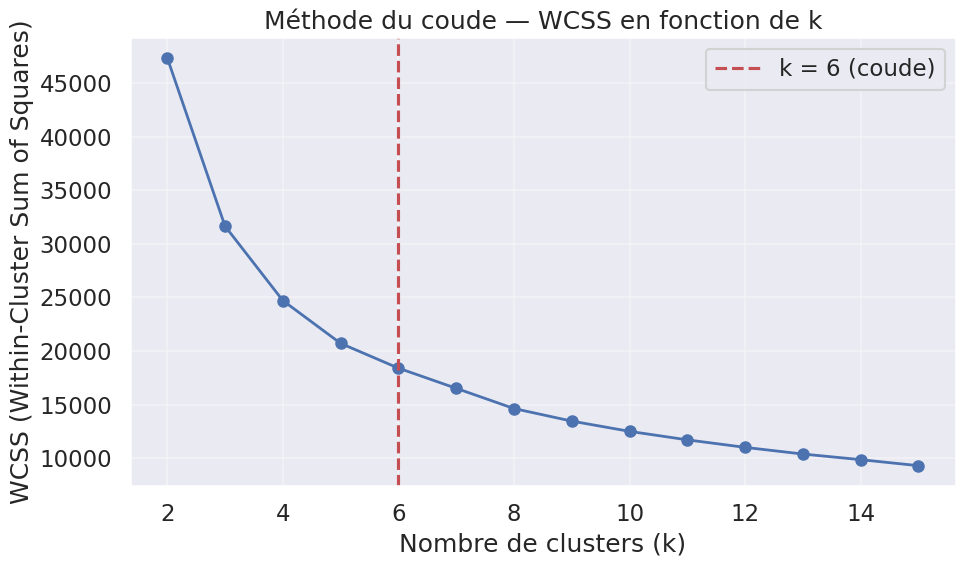

In [8]:
# Tracé de la courbe du coude
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), wcss, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=6, color='r', linestyle='--', label='k = 6 (coude)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Méthode du coude — WCSS en fonction de k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Le coude est observé à **k = 6** : au-delà, la réduction du WCSS ralentit significativement.

## 4. KMeans avec k = 6

In [9]:
# KMeans final
kmeans_final = KMeans(n_clusters=6, n_init=10, random_state=42)
clusters = kmeans_final.fit_predict(X_scaled)

# Ajout de la colonne cluster au dataframe original
housing['cluster'] = clusters

print("Répartition des clusters :")
print(housing['cluster'].value_counts().sort_index())

Répartition des clusters :
cluster
0    4766
1    5294
2     584
3    4882
4    3112
5    2002
Name: count, dtype: int64


In [10]:
# Statistiques par cluster
cluster_stats = housing.groupby('cluster').agg(
    effectif=('cluster', 'size'),
    prix_moyen=('median_house_value', 'mean'),
    revenu_moyen=('median_income', 'mean'),
    lat_moyenne=('latitude', 'mean'),
    lon_moyenne=('longitude', 'mean')
).round(2)

cluster_stats

,effectif,prix_moyen,revenu_moyen,lat_moyenne,lon_moyenne
cluster,,,,,
0,4766,213621.51,4.20,33.87,-118.03
1,5294,121905.23,2.82,38.17,-121.49
2,584,482953.35,10.36,35.60,-120.03
3,4882,126272.59,2.45,34.04,-117.91
4,3112,300858.82,4.94,37.64,-122.08
5,2002,385233.50,5.76,33.87,-118.17


## 5. Visualisation géographique des clusters

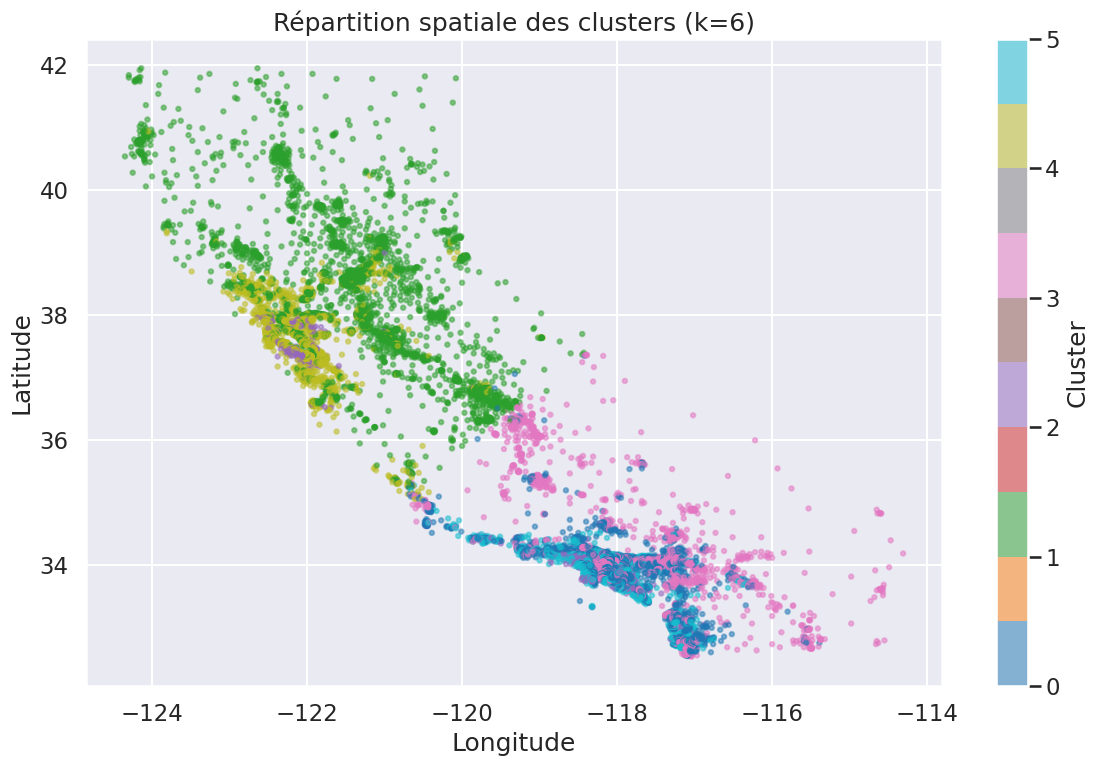

In [11]:
# Scatter plot latitude vs longitude coloré par cluster
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    housing['longitude'], housing['latitude'],
    c=housing['cluster'], cmap='tab10',
    alpha=0.5, s=10
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Répartition spatiale des clusters (k=6)')
plt.tight_layout()
plt.show()

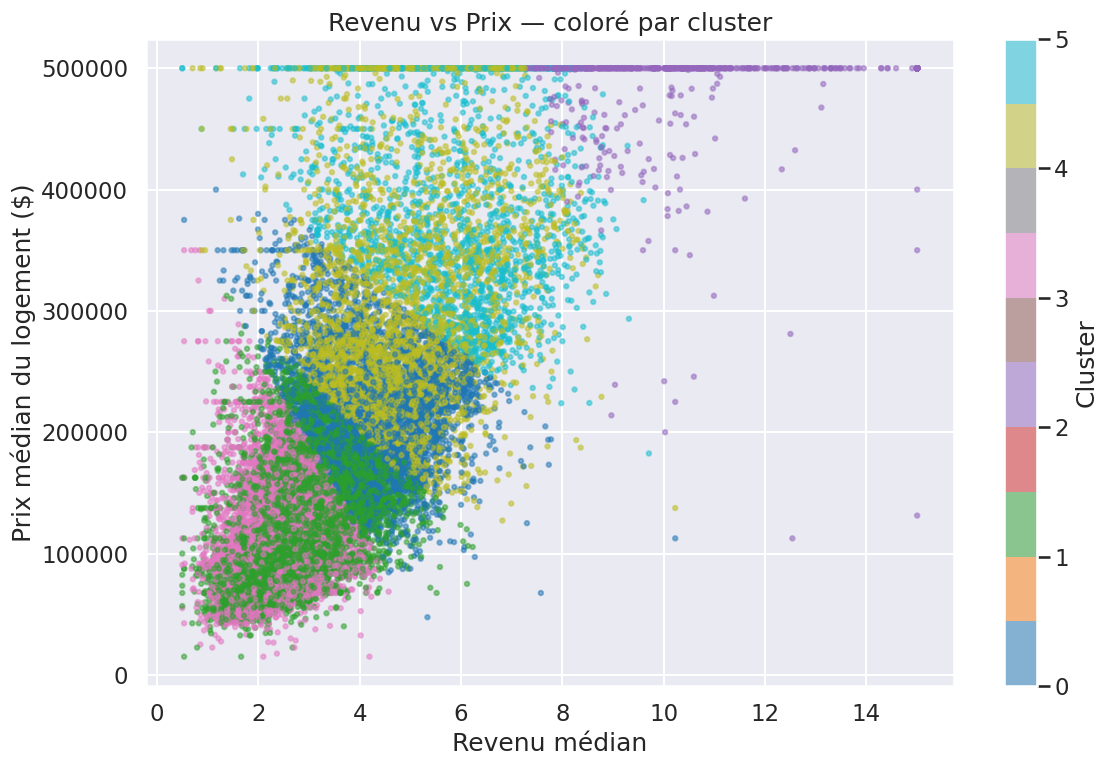

In [12]:
# Scatter plot revenu vs prix coloré par cluster
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    housing['median_income'], housing['median_house_value'],
    c=housing['cluster'], cmap='tab10',
    alpha=0.5, s=10
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Revenu médian')
plt.ylabel('Prix médian du logement ($)')
plt.title('Revenu vs Prix — coloré par cluster')
plt.tight_layout()
plt.show()

## 6. Export du dataset transformé

In [13]:
# Export avec la colonne cluster ajoutée
output_path = './data/housing_data_knn_clustered.csv'
housing.to_csv(output_path, index=False)
print(f"Dataset exporté : {output_path}")
print(f"Shape : {housing.shape}")
housing.head()

Dataset exporté : ./data/housing_data_knn_clustered.csv
Shape : (20640, 11)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,cluster
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,4
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,4
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4
